In [1]:
import sys
!{sys.executable} -m pip install gudhi persim numpy matplotlib astropy

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 9.9 MB 6.4 MB/s eta 0:00:01
     |████████████████████████████████| 48 kB 6.7 MB/s eta 0:00:01
     |████████████████████████████████| 6.4 MB 6.1 MB/s eta 0:00:01
     |████████████████████████████████| 174 kB 7.2 MB/s eta 0:00:01
     |████████████████████████████████| 2.0 MB 10.7 MB/s eta 0:00:01
     |████████████████████████████████| 14.0 MB 9.8 MB/s eta 0:00:01
     |████████████████████████████████| 329 kB 6.8 MB/s eta 0:00:01
     |████████████████████████████████| 81 kB 6.7 MB/s eta 0:00:01
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18119 sha256=956f36394759ba9ee45a358b990ecee94beb3c8bbec0f8af591d712ebfc63f86
  Stored in directory: /Users/thomasgould/Library/Caches/pip/wheels/57/16/69/97f76cd294aad962fc5e1a15ab19c07fd885016deda8f200c3
Successfully built hopcroftkarp
  Attempting uninstall: numpy
    Found existing ins

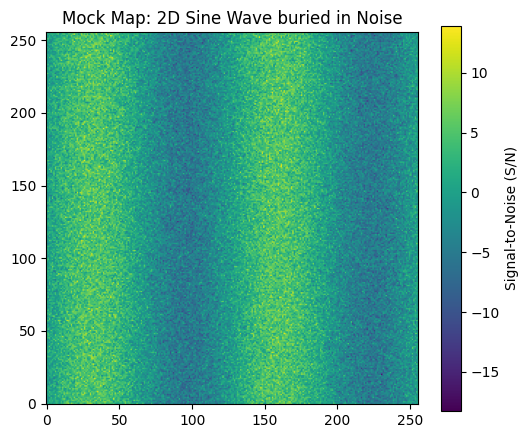

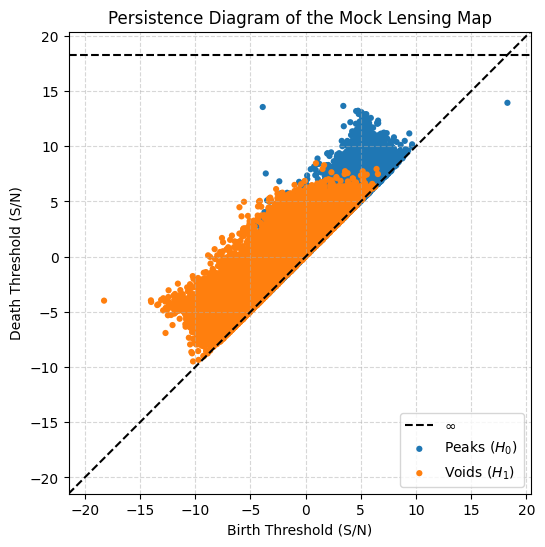

In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import gudhi as gd
import persim

#step 1 generate map

grid_size = 256
x = np.linspace(0, 4 * np.pi, grid_size)
y = np.linspace(0, 4 * np.pi, grid_size)
X, Y = np.meshgrid(x, y)

#generate 2d sine wave signal

signal = 5 * np.sin(x)

#generate random noise

noise = np.random.normal(loc=0, scale=2.5, size=(grid_size, grid_size))

#combine signal and noise to create mock lensing map
mock_map = signal + noise

#plot the mock map
fig1, ax1 = plt.subplots(figsize=(6, 5))
im = ax1.imshow(mock_map, cmap='viridis', origin='lower')
fig1.colorbar(im, ax=ax1, label='Signal-to-Noise (S/N)')
ax1.set_title("Mock Map: 2D Sine Wave buried in Noise")

#step 2 compute persistent homology with GUDHI

inverted_map = -1 * mock_map

#initialize GUDHI's cubical complex
cubical_complex = gd.CubicalComplex(
    dimensions=inverted_map.shape,
    top_dimensional_cells=inverted_map.flatten()
)

#run filtration sweep
persistence_raw = cubical_complex.persistence()

#extract birth-death pairs for H0 (peaks) and H1 (voids)
pairs_H0 = cubical_complex.persistence_intervals_in_dimension(0)
pairs_H1 = cubical_complex.persistence_intervals_in_dimension(1)

#flip birth-death back to original physical scales
births_H0, deaths_H0 = -pairs_H0[:, 1], -pairs_H0[:, 0]
births_H1, deaths_H1 = -pairs_H1[:, 1], -pairs_H1[:, 0]

#combine into clean 2D numpy arrays for plotting engine
clean_H0 = np.column_stack((births_H0, deaths_H0))
clean_H1 = np.column_stack((births_H1, deaths_H1))

#step 3 visualize persistence diagram
fig2, ax2 = plt.subplots(figsize=(6, 6))
#pass the 'ax' (axes) variable into the persim so it draws inside the VS code window
persim.plot_diagrams([clean_H0, clean_H1],
                    labels=['Peaks ($H_0$)', 'Voids ($H_1$)'],
                    ax=ax2)

ax2.set_title("Persistence Diagram of the Mock Lensing Map")
ax2.set_xlabel("Birth Threshold (S/N)")
ax2.set_ylabel("Death Threshold (S/N)")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.show()